<a href="https://colab.research.google.com/github/mathsrm/fcd-sleep-health-lifestyle-eda/blob/main/notebooks/analise_sono.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Indicadores de Sono, Saúde e Estilo de Vida

**Base de dados:** *Sleep Health and Lifestyle Dataset* — Kaggle  
**Objetivo:** realizar uma análise exploratória da base, observando distribuições, padrões visuais e possíveis associações entre variáveis relacionadas ao sono, saúde e estilo de vida.

> Observação importante: este notebook tem caráter exploratório. Assim, as análises apresentadas não têm como objetivo testar hipóteses, estimar efeitos causais ou fazer inferência estatística. As interpretações devem ser feitas com cautela e restritas à base analisada.

## 1. Importação das bibliotecas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 2. Carregamento da base de dados

In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 3. Primeira inspeção dos dados

Antes de limpar ou transformar os dados, é importante verificar o tamanho da base, os nomes das colunas, os tipos das variáveis e a presença de valores ausentes.

In [ ]:
print(f'Quantidade de linhas: {df_original.shape[0]}')
print(f'Quantidade de colunas: {df_original.shape[1]}')

df_original.info()

Quantidade de linhas: 374
Quantidade de colunas: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), obj

In [ ]:
df_original.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.00,374,374.00,374,374.00,374.00,374.00,374.00,374,374,374.00,374.00,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.50,NaN,42.18,NaN,7.13,7.31,59.17,5.39,NaN,NaN,70.17,6816.84,NaN
std,108.11,NaN,8.67,NaN,0.80,1.20,20.83,1.77,NaN,NaN,4.14,1617.92,NaN
min,1.00,NaN,27.00,NaN,5.80,4.00,30.00,3.00,NaN,NaN,65.00,3000.00,NaN
25%,94.25,NaN,35.25,NaN,6.40,6.00,45.00,4.00,NaN,NaN,68.00,5600.00,NaN
50%,187.50,NaN,43.00,NaN,7.20,7.00,60.00,5.00,NaN,NaN,70.00,7000.00,NaN
75%,280.75,NaN,50.00,NaN,7.80,8.00,75.00,7.00,NaN,NaN,72.00,8000.00,NaN


In [ ]:
valores_ausentes = df_original.isna().sum().sort_values(ascending=False)
valores_ausentes[valores_ausentes > 0]

,0
Sleep Disorder,219


In [ ]:
print(f'Quantidade de linhas duplicadas: {df_original.duplicated().sum()}')

Quantidade de linhas duplicadas: 0


## 4. Limpeza e pré-processamento dos dados

Nesta etapa, serão feitas transformações simples para facilitar a análise:

- padronização dos nomes das colunas;
- remoção de duplicatas, se existirem;
- tratamento da coluna de distúrbio do sono;
- separação da pressão arterial em pressão sistólica e diastólica;
- conferência dos tipos das variáveis.

In [ ]:
def padronizar_colunas(colunas):
    return (
        colunas
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace('-', '_', regex=False)
    )

df = df_original.copy()
df.columns = padronizar_colunas(df.columns)

df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
linhas_antes = df.shape[0]
df = df.drop_duplicates()
linhas_depois = df.shape[0]

print(f'Linhas antes da remoção de duplicatas: {linhas_antes}')
print(f'Linhas depois da remoção de duplicatas: {linhas_depois}')
print(f'Duplicatas removidas: {linhas_antes - linhas_depois}')

Linhas antes da remoção de duplicatas: 374
Linhas depois da remoção de duplicatas: 374
Duplicatas removidas: 0


In [ ]:
if 'sleep_disorder' in df.columns:
    df['sleep_disorder'] = df['sleep_disorder'].fillna('Nenhum')
    df['sleep_disorder'] = df['sleep_disorder'].replace({'None': 'Nenhum', 'No Sleep Disorder': 'Nenhum'})

if 'bmi_category' in df.columns:
    df['bmi_category'] = df['bmi_category'].replace({'Normal Weight': 'Normal'})

if 'blood_pressure' in df.columns:
    pressao = df['blood_pressure'].astype(str).str.split('/', expand=True)
    df['systolic_pressure'] = pd.to_numeric(pressao[0], errors='coerce')
    df['diastolic_pressure'] = pd.to_numeric(pressao[1], errors='coerce')

df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder,systolic_pressure,diastolic_pressure
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,Nenhum,126,83
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,Nenhum,125,80
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,Nenhum,125,80
3,4,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [ ]:
print('Valores ausentes após tratamento:')
display(df.isna().sum().sort_values(ascending=False))

print('\nTipos das variáveis:')
display(df.dtypes)

Valores ausentes após tratamento:


,0
person_id,0
gender,0
age,0
occupation,0
sleep_duration,0
quality_of_sleep,0
physical_activity_level,0
stress_level,0
bmi_category,0
blood_pressure,0



Tipos das variáveis:


,0
person_id,int64
gender,object
age,int64
occupation,object
sleep_duration,float64
quality_of_sleep,int64
physical_activity_level,int64
stress_level,int64
bmi_category,object
blood_pressure,object


## 5. Dicionário resumido das variáveis

A tabela abaixo resume as principais variáveis utilizadas na análise.

In [ ]:
dicionario = pd.DataFrame({
    'Variável': [
        'gender', 'age', 'occupation', 'sleep_duration', 'quality_of_sleep',
        'physical_activity_level', 'stress_level', 'bmi_category',
        'heart_rate', 'daily_steps', 'sleep_disorder',
        'systolic_pressure', 'diastolic_pressure'
    ],
    'Descrição': [
        'Gênero da pessoa registrada na base',
        'Idade',
        'Ocupação/profissão',
        'Duração do sono em horas',
        'Indicador de qualidade do sono',
        'Nível de atividade física',
        'Nível de estresse',
        'Categoria de IMC',
        'Frequência cardíaca',
        'Quantidade de passos diários',
        'Registro de distúrbio do sono',
        'Pressão arterial sistólica',
        'Pressão arterial diastólica'
    ],
    'Tipo de análise': [
        'Categórica', 'Numérica', 'Categórica', 'Numérica', 'Numérica/ordinal',
        'Numérica/ordinal', 'Numérica/ordinal', 'Categórica',
        'Numérica', 'Numérica', 'Categórica', 'Numérica', 'Numérica'
    ]
})

dicionario

,Variável,Descrição,Tipo de análise
0,gender,Gênero da pessoa registrada na base,Categórica
1,age,Idade,Numérica
2,occupation,Ocupação/profissão,Categórica
3,sleep_duration,Duração do sono em horas,Numérica
4,quality_of_sleep,Indicador de qualidade do sono,Numérica/ordinal
5,physical_activity_level,Nível de atividade física,Numérica/ordinal
6,stress_level,Nível de estresse,Numérica/ordinal
7,bmi_category,Categoria de IMC,Categórica
8,heart_rate,Frequência cardíaca,Numérica
9,daily_steps,Quantidade de passos diários,Numérica


## 6. Análise descritiva inicial

Primeiro, são observadas medidas descritivas das variáveis numéricas e frequências das variáveis categóricas. Essa etapa ajuda a entender a estrutura geral da base antes dos gráficos.

In [ ]:
variaveis_numericas = df.select_dtypes(include=np.number).columns.tolist()

df[variaveis_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,374.00,187.50,108.11,1.00,94.25,187.50,280.75,374.00
age,374.00,42.18,8.67,27.00,35.25,43.00,50.00,59.00
sleep_duration,374.00,7.13,0.80,5.80,6.40,7.20,7.80,8.50
quality_of_sleep,374.00,7.31,1.20,4.00,6.00,7.00,8.00,9.00
physical_activity_level,374.00,59.17,20.83,30.00,45.00,60.00,75.00,90.00
stress_level,374.00,5.39,1.77,3.00,4.00,5.00,7.00,8.00
heart_rate,374.00,70.17,4.14,65.00,68.00,70.00,72.00,86.00
daily_steps,374.00,6816.84,1617.92,3000.00,5600.00,7000.00,8000.00,10000.00
systolic_pressure,374.00,128.55,7.75,115.00,125.00,130.00,135.00,142.00
diastolic_pressure,374.00,84.65,6.16,75.00,80.00,85.00,90.00,95.00


In [ ]:
variaveis_categoricas = df.select_dtypes(exclude=np.number).columns.tolist()

for col in variaveis_categoricas:
    print(f'\nFrequência da variável: {col}')
    display(df[col].value_counts(dropna=False).to_frame('frequência'))
    print(f'\n')


Frequência da variável: gender


,frequência
gender,
Male,189
Female,185





Frequência da variável: occupation


,frequência
occupation,
Nurse,73
Doctor,71
Engineer,63
Lawyer,47
Teacher,40
Accountant,37
Salesperson,32
Scientist,4
Software Engineer,4





Frequência da variável: bmi_category


,frequência
bmi_category,
Normal,216
Overweight,148
Obese,10





Frequência da variável: blood_pressure


,frequência
blood_pressure,
130/85,99
140/95,65
125/80,65
120/80,45
115/75,32
135/90,27
140/90,4
125/82,4
128/85,3





Frequência da variável: sleep_disorder


,frequência
sleep_disorder,
Nenhum,219
Sleep Apnea,78
Insomnia,77


## 7. Distribuição da duração do sono

O histograma permite observar como os valores de duração do sono estão distribuídos na base analisada.

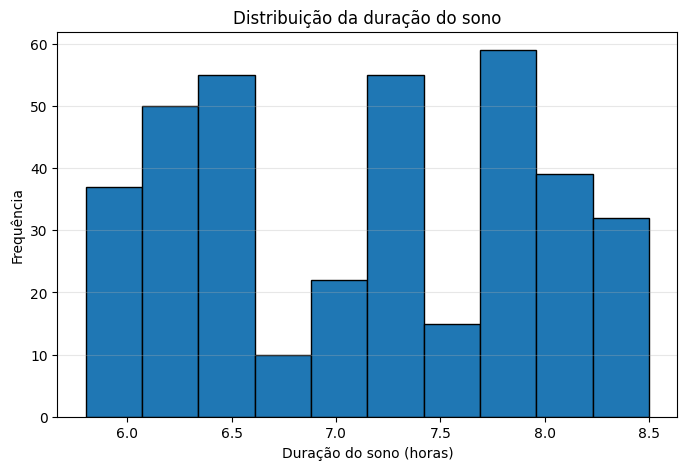

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['sleep_duration'], bins=10, edgecolor='black')
plt.title('Distribuição da duração do sono')
plt.xlabel('Duração do sono (horas)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.show()

A partir do histograma, é possível observar a concentração dos valores de duração do sono na base. Essa análise permite descrever a distribuição dos dados, sem afirmar que ela representa necessariamente um padrão geral da população.

## 8. Distribuição da qualidade do sono

O gráfico de barras mostra a frequência de cada valor de qualidade do sono registrado na base.

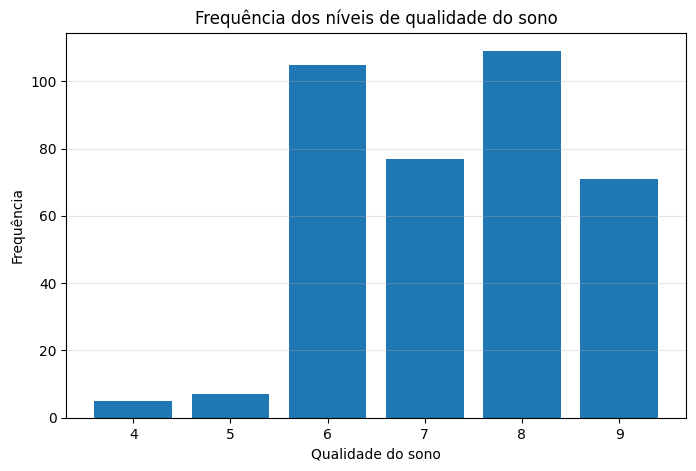

In [ ]:
qualidade_freq = df['quality_of_sleep'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(qualidade_freq.index.astype(str), qualidade_freq.values)
plt.title('Frequência dos níveis de qualidade do sono')
plt.xlabel('Qualidade do sono')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.show()

O gráfico permite observar quais níveis de qualidade do sono aparecem com maior frequência na base analisada. Essa etapa é descritiva e serve como ponto de partida para comparações com outras variáveis.

## 9. Qualidade do sono por categoria de IMC

O boxplot permite comparar visualmente a distribuição da qualidade do sono entre diferentes categorias de IMC.

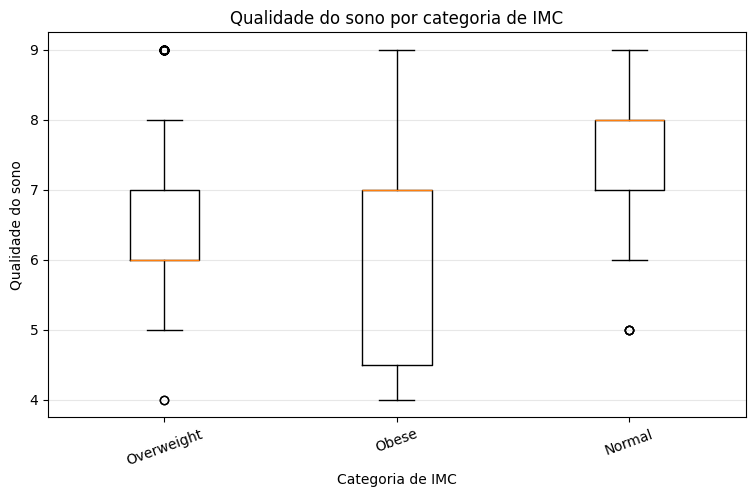

In [ ]:
ordem_bmi = df.groupby('bmi_category')['quality_of_sleep'].median().sort_values().index

dados_boxplot = [df.loc[df['bmi_category'] == cat, 'quality_of_sleep'] for cat in ordem_bmi]

plt.figure(figsize=(9, 5))
plt.boxplot(dados_boxplot, tick_labels=ordem_bmi, patch_artist=False)
plt.title('Qualidade do sono por categoria de IMC')
plt.xlabel('Categoria de IMC')
plt.ylabel('Qualidade do sono')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.show()

In [ ]:
tabela_bmi_sono = (
    df.groupby('bmi_category')['quality_of_sleep']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('median', ascending=False)
)

tabela_bmi_sono

,count,mean,median,min,max
bmi_category,,,,,
Normal,216,7.64,8.00,5,9
Obese,10,6.40,7.00,4,9
Overweight,148,6.90,6.00,4,9


O boxplot sugere possíveis diferenças na distribuição da qualidade do sono entre categorias de IMC. No entanto, como a análise é exploratória, esses padrões devem ser interpretados apenas como indicações visuais dentro da base analisada.

## 10. Nível de estresse e qualidade do sono

O gráfico de dispersão permite observar visualmente como os valores de qualidade do sono se distribuem em relação ao nível de estresse.

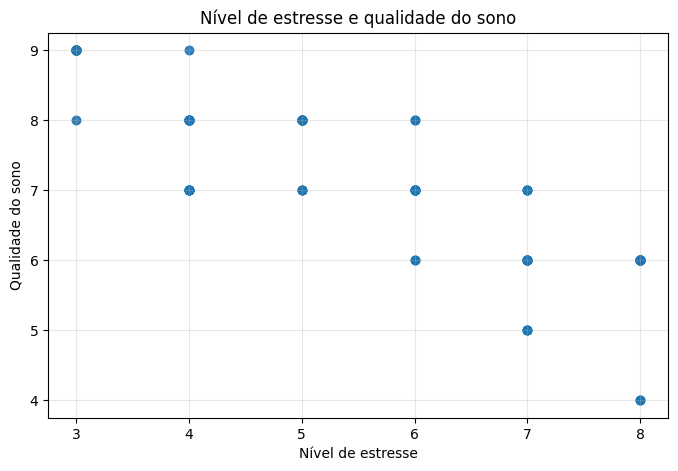

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['stress_level'], df['quality_of_sleep'], alpha=0.7)
plt.title('Nível de estresse e qualidade do sono')
plt.xlabel('Nível de estresse')
plt.ylabel('Qualidade do sono')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
tabela_estresse_sono = (
    df.groupby('stress_level')['quality_of_sleep']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_index()
)

tabela_estresse_sono

,count,mean,median,min,max
stress_level,,,,,
3,71,8.97,9.00,8,9
4,70,7.67,8.00,7,9
5,67,7.90,8.00,7,8
6,46,7.00,7.00,6,8
7,50,6.00,6.00,5,7
8,70,5.86,6.00,4,6


Na base analisada, o gráfico permite observar se há um padrão visual entre nível de estresse e qualidade do sono.

## 11. Duração do sono por ocupação

Esta análise compara a duração do sono entre ocupações. Como algumas ocupações podem ter poucos registros, é importante observar também a quantidade de pessoas em cada grupo.

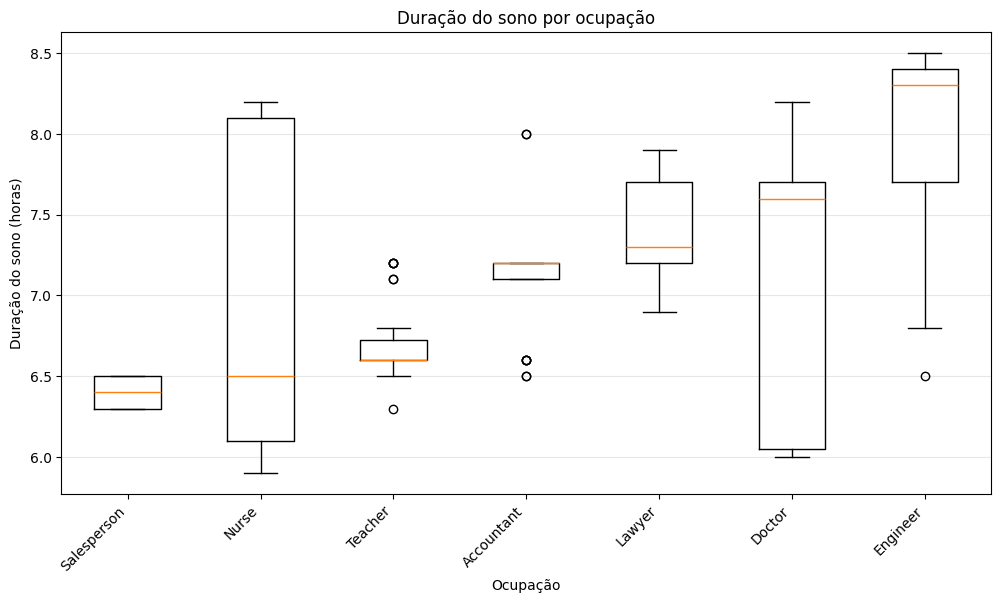

In [ ]:
ocupacoes_contagem = df['occupation'].value_counts()
ocupacoes_validas = ocupacoes_contagem[ocupacoes_contagem >= 5].index

df_ocupacoes = df[df['occupation'].isin(ocupacoes_validas)].copy()
ordem_ocupacao = df_ocupacoes.groupby('occupation')['sleep_duration'].median().sort_values().index

dados_boxplot = [df_ocupacoes.loc[df_ocupacoes['occupation'] == oc, 'sleep_duration'] for oc in ordem_ocupacao]

plt.figure(figsize=(12, 6))
plt.boxplot(dados_boxplot, tick_labels=ordem_ocupacao, patch_artist=False)
plt.title('Duração do sono por ocupação')
plt.xlabel('Ocupação')
plt.ylabel('Duração do sono (horas)')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
tabela_ocupacao_sono = (
    df_ocupacoes.groupby('occupation')['sleep_duration']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('median', ascending=False)
)

tabela_ocupacao_sono

,count,mean,median,min,max
occupation,,,,,
Engineer,63,7.99,8.30,6.50,8.50
Doctor,71,6.97,7.60,6.00,8.20
Lawyer,47,7.41,7.30,6.90,7.90
Accountant,37,7.11,7.20,6.50,8.00
Teacher,40,6.69,6.60,6.30,7.20
Nurse,73,7.06,6.50,5.90,8.20
Salesperson,32,6.40,6.40,6.30,6.50


A comparação por ocupação permite observar diferenças descritivas na duração do sono entre grupos. Essas diferenças podem estar associadas a características do grupo na própria base, mas não devem ser interpretadas como efeito direto da ocupação sobre o sono.

## 12. Distúrbios do sono por categoria de IMC

O gráfico de barras empilhadas permite observar como os registros de distúrbios do sono se distribuem entre categorias de IMC.

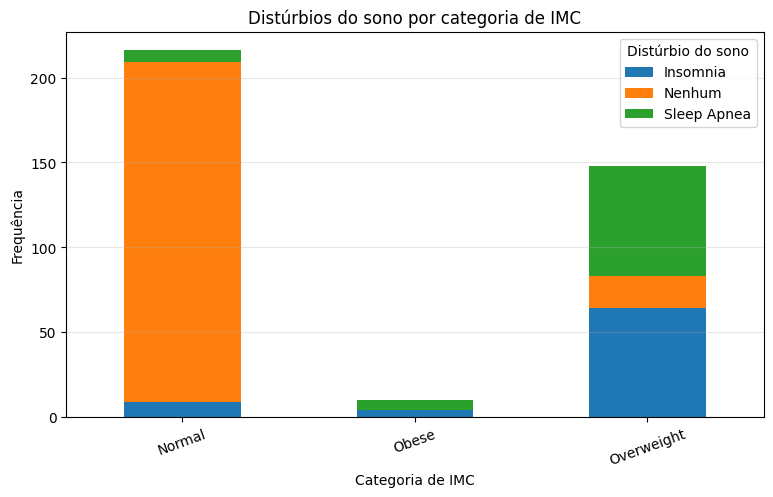

sleep_disorder,Insomnia,Nenhum,Sleep Apnea
bmi_category,,,
Normal,9,200,7
Obese,4,0,6
Overweight,64,19,65


In [ ]:
tabela_disturbio_bmi = pd.crosstab(df['bmi_category'], df['sleep_disorder'])

tabela_disturbio_bmi.plot(kind='bar', stacked=True, figsize=(9, 5))
plt.title('Distúrbios do sono por categoria de IMC')
plt.xlabel('Categoria de IMC')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.legend(title='Distúrbio do sono')
plt.show()

tabela_disturbio_bmi

O gráfico mostra a frequência dos tipos de distúrbio do sono dentro de cada categoria de IMC. Essa visualização ajuda a identificar padrões na amostra, mas não permite concluir que uma categoria de IMC provoque determinado distúrbio.

## 13. Comparação descritiva entre pessoas com e sem distúrbio do sono

Nesta etapa, é criada uma variável simplificada indicando se há ou não registro de distúrbio do sono. Em seguida, são comparadas algumas variáveis numéricas entre os grupos.

In [ ]:
df['tem_disturbio_sono'] = np.where(df['sleep_disorder'] == 'Nenhum', 'Sem distúrbio registrado', 'Com distúrbio registrado')

variaveis_comparacao = [
    'sleep_duration', 'quality_of_sleep', 'physical_activity_level',
    'stress_level', 'heart_rate', 'daily_steps',
    'systolic_pressure', 'diastolic_pressure'
]

variaveis_comparacao = [col for col in variaveis_comparacao if col in df.columns]

tabela_disturbio = (
    df.groupby('tem_disturbio_sono')[variaveis_comparacao]
    .agg(['count', 'mean', 'median'])
)

tabela_disturbio

sleep_duration             quality_of_sleep       \
                                  count mean median            count mean   
tem_disturbio_sono                                                          
Com distúrbio registrado            155 6.81   6.50              155 6.87   
Sem distúrbio registrado            219 7.36   7.40              219 7.63   

                                physical_activity_level               \
                         median                   count  mean median   
tem_disturbio_sono                                                     
Com distúrbio registrado   7.00                     155 60.90  45.00   
Sem distúrbio registrado   8.00                     219 57.95  60.00   

                         stress_level             heart_rate               \
                                count mean median      count  mean median   
tem_disturbio_sono                                                          
Com distúrbio registrado          155 5.77   7.00        155 71.79  72.00   
Sem distúrbio registrado          219 5.11   5.00        219 69.02  70.00   

                         daily_steps                 systolic_pressure         \
                               count    mean  median             count   mean   
tem_disturbio_sono                                                              
Com distúrbio registrado         155 6765.81 6000.00               155 134.92   
Sem distúrbio registrado         219 6852.97 7000.00               219 124.05   

                                diastolic_pressure               
                         median              count  mean median  
tem_disturbio_sono                                               
Com distúrbio registrado 135.00                155 89.81  90.00  
Sem distúrbio registrado 125.00                219 81.00  80.00

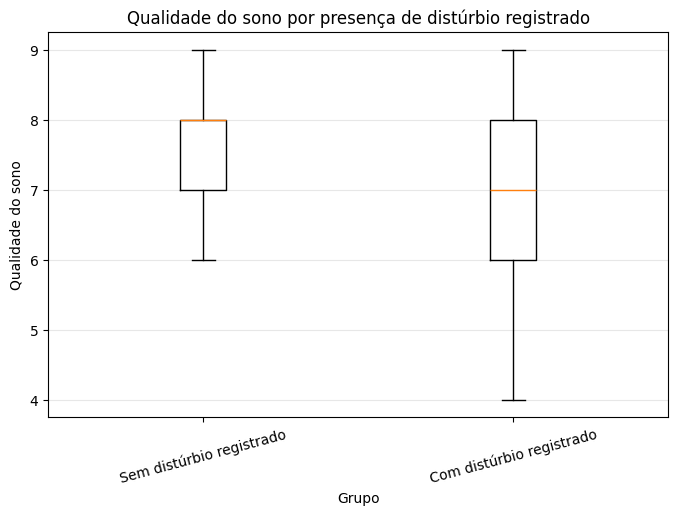

In [ ]:
plt.figure(figsize=(8, 5))

grupos = df['tem_disturbio_sono'].unique()
dados_boxplot = [df.loc[df['tem_disturbio_sono'] == grupo, 'quality_of_sleep'] for grupo in grupos]

plt.boxplot(dados_boxplot, tick_labels=grupos, patch_artist=False)
plt.title('Qualidade do sono por presença de distúrbio registrado')
plt.xlabel('Grupo')
plt.ylabel('Qualidade do sono')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.show()

A tabela e o boxplot permitem observar diferenças descritivas entre pessoas com e sem registro de distúrbio do sono na base. Como não foram realizados testes estatísticos, as diferenças observadas devem ser descritas como padrões da amostra.

## 14. Síntese dos principais padrões observados

A célula abaixo serve como apoio para escrever a conclusão do relatório. Complete os itens com base nos gráficos e tabelas gerados.

A análise exploratória da base *Sleep Health and Lifestyle Dataset* permitiu observar padrões descritivos relacionados à duração do sono, qualidade do sono, hábitos de vida e indicadores de saúde dos indivíduos registrados. Inicialmente, a distribuição da duração do sono mostrou que os valores se concentram em uma faixa intermediária de horas, com variações entre os indivíduos da base analisada.

Ao comparar os grupos, os gráficos sugerem possíveis diferenças na qualidade do sono entre as categorias de IMC. Em algumas categorias, observa-se maior dispersão dos valores, o que indica que a qualidade do sono não se comporta de maneira totalmente uniforme entre os grupos. No entanto, por se tratar de uma análise exploratória, essas diferenças devem ser interpretadas apenas como padrões observados na amostra.

Também foi possível observar visualmente uma possível associação entre nível de estresse e qualidade do sono. De modo geral, os gráficos sugerem que indivíduos com maiores níveis de estresse tendem a apresentar menores valores de qualidade do sono na base analisada. Ainda assim, essa observação não permite afirmar que o estresse causa piora na qualidade do sono, pois não foram aplicadas técnicas de inferência estatística ou modelos causais.

A comparação entre pessoas com e sem distúrbio do sono registrado também indicou diferenças descritivas em algumas variáveis, como duração do sono, qualidade do sono e nível de estresse. Esses resultados sugerem que a presença de distúrbios do sono pode estar associada a diferentes perfis dentro da base, mas essa interpretação deve ser feita com cautela.

De modo geral, a análise exploratória indicou possíveis padrões entre sono, estilo de vida e indicadores de saúde. Entretanto, os resultados se limitam à base analisada e não devem ser generalizados para toda a população. Para conclusões mais robustas, seriam necessários estudos adicionais, com controle de variáveis, amostras mais amplas e aplicação de métodos estatísticos apropriados.


## 15. Limitações da análise

Algumas limitações importantes devem ser consideradas:

- a base representa apenas os indivíduos registrados no conjunto de dados;
- não foram aplicados testes estatísticos de hipótese;
- não é possível afirmar causalidade entre as variáveis;
- algumas categorias possuem quantidades diferentes de observações;
- variáveis importantes para o sono podem não estar presentes na base.

## 16. Exportação da base tratada

A célula abaixo salva a base tratada em um novo arquivo CSV.

In [ ]:
df.to_csv('sleep_health_lifestyle_tratada.csv', index=False)

print('Arquivo salvo: sleep_health_lifestyle_tratada.csv')

Arquivo salvo: sleep_health_lifestyle_tratada.csv


## 17. Conclusão preliminar

Este notebook apresentou uma análise exploratória da base *Sleep Health and Lifestyle Dataset*, com foco na observação de padrões descritivos relacionados ao sono, à saúde e ao estilo de vida dos indivíduos registrados. Ao longo da análise, foram utilizadas tabelas descritivas e diferentes tipos de visualização, como histogramas, gráficos de barras, gráficos de dispersão, boxplots e mapa de correlação.

Por se tratar de uma análise exploratória, não foram realizadas inferências estatísticas nem testes de significância. Portanto, os resultados não permitem afirmar causalidade, comprovar relações entre variáveis ou generalizar conclusões para toda a população. Ainda assim, a análise fornece um panorama inicial da base e pode servir como ponto de partida para estudos futuros mais aprofundados sobre possíveis associações entre sono, saúde e estilo de vida.
